# Disease Prediction Using Machine Learning

## CodeAlpha Machine Learning Internship

### Project Overview

Early disease prediction can assist healthcare professionals in making timely decisions by analyzing patient symptoms and medical attributes. This project develops a supervised machine learning model capable of predicting diseases based on patient data.

The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, and prediction.

## Objectives

The objectives of this project are:

- Understand the medical dataset.
- Perform data cleaning and preprocessing.
- Explore the dataset through visualization.
- Train multiple machine learning models.
- Compare model performance.
- Select the best-performing model.
- Predict diseases using new patient information.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Jupyter Notebook (VS Code)

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Train-Test Split
7. Model Training
8. Model Comparison
9. Model Evaluation
10. Save Best Model
11. Disease Prediction
12. Conclusion

# Import Libraries

The following libraries are imported for data manipulation, visualization, machine learning model development, evaluation, and model persistence.

In [33]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Save Model
import joblib

# Load the Dataset

The Heart Disease dataset is obtained directly from the UCI Machine Learning Repository using the official `ucimlrepo` package. This ensures the dataset source is authentic and reproducible.

In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Features and target
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into one DataFrame
df = X.copy()
df["target"] = y

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# Dataset Overview

Before building machine learning models, it is important to understand the dataset's structure, features, and quality.

This section explores:
- Dataset dimensions
- Feature names
- Data types
- Statistical summary
- Missing values

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (303, 14)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## Observations

- The dataset contains clinical information for heart disease prediction.
- Features include patient demographics, chest pain type, blood pressure, cholesterol level, ECG results, and other medical measurements.
- Missing values, if present, will be handled during preprocessing.
- The target variable indicates the presence of heart disease.

# Data Cleaning

Data cleaning is an essential preprocessing step before training machine learning models.

In this section, we will:

- Check for missing values.
- Handle missing values appropriately.
- Verify duplicate records.
- Prepare the dataset for exploratory data analysis and model training.

In [10]:
# Check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [11]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Handling Missing Values

The dataset contains a small number of missing values in the `ca` and `thal` features.

Since both variables represent categorical/discrete medical attributes, missing values are replaced using the **mode (most frequent value)**. This preserves the integrity of the dataset without removing valuable samples.

In [14]:
# Fill missing values using mode

# Fill missing values using mode

df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [15]:
# Verify missing values after preprocessing

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Target Variable Analysis

The target variable represents the diagnosis of heart disease.

Before training machine learning models, we analyze the distribution of the target classes to understand the dataset balance.

In [16]:
# Display target value counts

df["target"].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

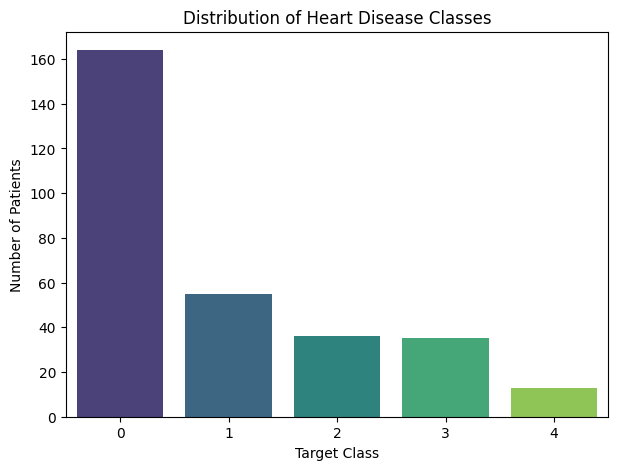

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="target",
    palette="viridis"
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.show()

# Target Variable Preprocessing

The original target variable contains five classes (0–4), where 0 indicates the absence of heart disease and 1–4 represent increasing severity levels.

For this project, the target variable is converted into a binary classification problem:

- **0:** No Heart Disease
- **1:** Heart Disease

This simplifies the prediction task and makes the model suitable for early disease screening.

In [18]:
# Convert multiclass target to binary

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps in understanding the characteristics of the dataset through statistical summaries and visualizations.

The objectives of this analysis are:

- Understand the distribution of important features.
- Identify relationships between variables.
- Detect possible outliers.
- Explore how different features relate to heart disease.

## Distribution of Heart Disease

This visualization shows the number of patients with and without heart disease after converting the target variable into binary classes.

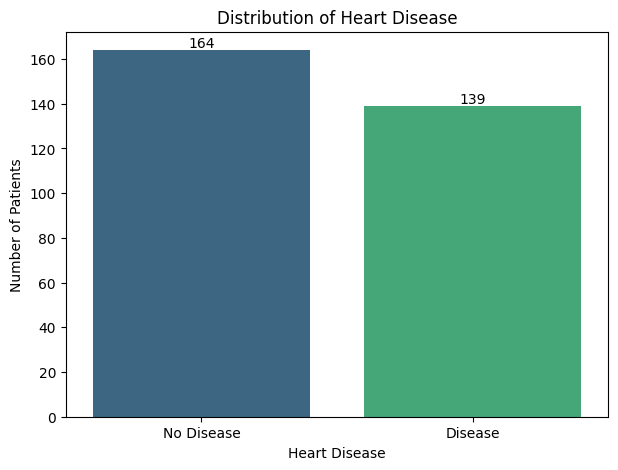

In [20]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="target",
    hue="target",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["No Disease","Disease"])

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

- The dataset is relatively balanced after converting the target into binary classes.
- There are 164 patients without heart disease and 139 patients with heart disease.
- A balanced dataset helps machine learning models learn both classes more effectively.

## Age Distribution

This histogram shows the age distribution of patients in the dataset.

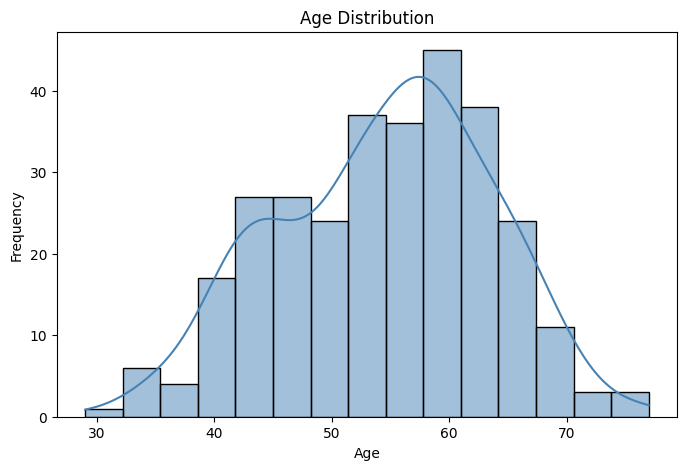

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most patients belong to the middle-aged and older age groups.
- The age distribution appears approximately normal with a concentration around the middle age range.

## Gender Distribution

This visualization illustrates the distribution of male and female patients in the dataset.


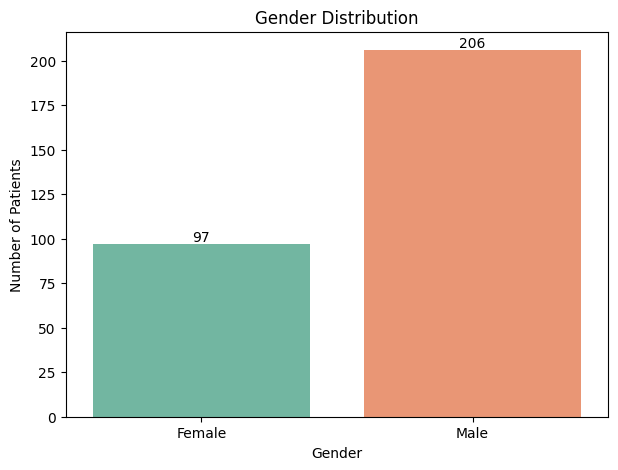

In [22]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="sex",
    hue="sex",
    palette="Set2",
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["Female","Male"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

- The dataset contains more male patients than female patients.
- This imbalance should be considered when interpreting model performance across genders.

## Correlation Heatmap

A correlation heatmap helps identify relationships between numerical features and the target variable.

Correlation values range from **-1 to +1**:
- **+1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

Understanding these relationships helps identify the most influential features for prediction.

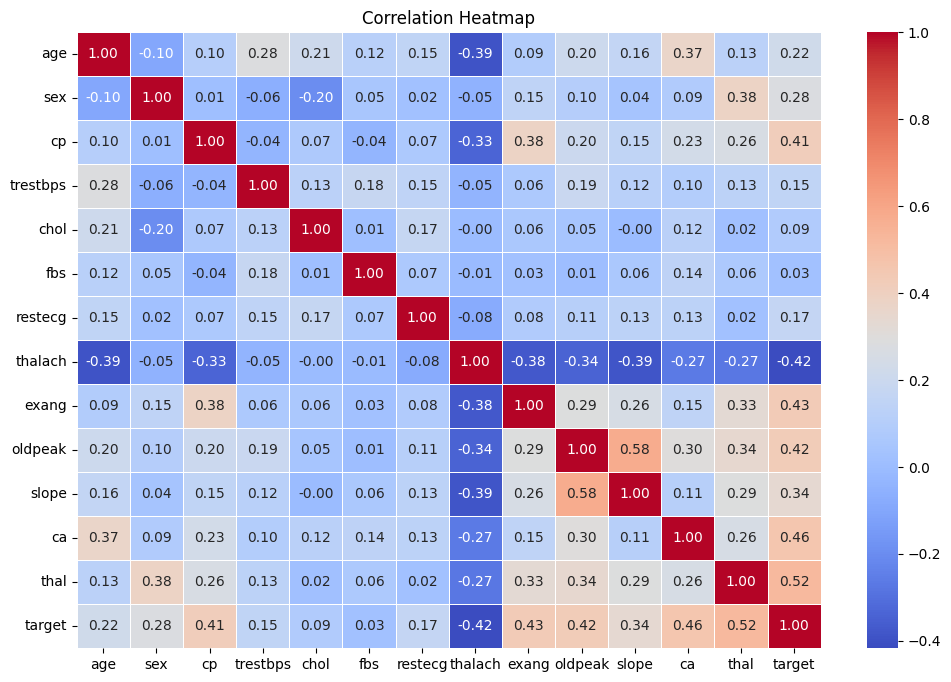

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


### Observation

- The heatmap illustrates the correlation between all numerical features.
- Features with higher positive or negative correlation with the target may have greater predictive importance.
- Correlation does not necessarily imply causation, but it provides useful insights during feature analysis.

## Heart Disease by Age

This visualization compares the age distribution of patients with and without heart disease.

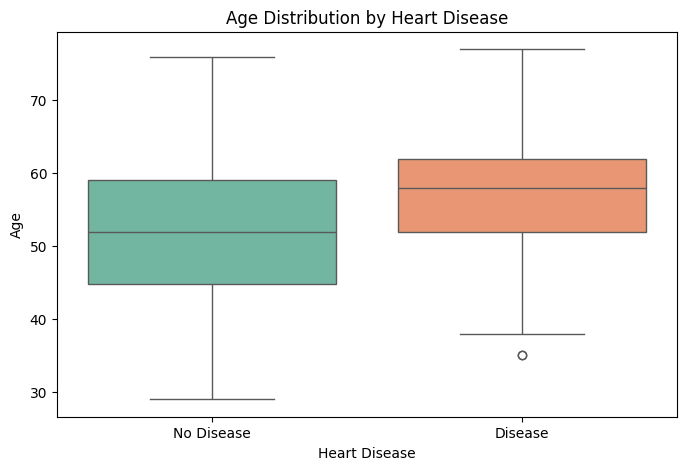

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="age",
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0,1],["No Disease","Disease"])

plt.show()

### Observation

- Patients diagnosed with heart disease tend to be older on average.
- The boxplot also highlights the spread of ages and any potential outliers in each class.

# Feature Engineering and Data Preparation

Before training machine learning models, the dataset is prepared by separating the input features from the target variable.

The dataset is then divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [25]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (303, 13)
Target Vector Shape: (303,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (242, 13)
Testing Features : (61, 13)
Training Labels : (242,)
Testing Labels  : (61,)


### Observation

- The dataset has been successfully divided into training and testing sets.
- 80% of the data is used for training, while 20% is reserved for testing.
- Stratified sampling ensures that both classes remain proportionally represented in each subset.

# Model 1: Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem. It assumes that the features are independent and normally distributed.

It is simple, fast, and often serves as a strong baseline model for classification tasks.

In [28]:
# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create Model
gnb = GaussianNB()

# Train Model
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [29]:
# Predict on test data
y_pred_gnb = gnb.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian Naive Bayes Accuracy: {gnb_accuracy:.4f}")

Gaussian Naive Bayes Accuracy: 0.8689


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.96      0.79      0.87        33
           1       0.79      0.96      0.87        28

    accuracy                           0.87        61
   macro avg       0.88      0.88      0.87        61
weighted avg       0.89      0.87      0.87        61



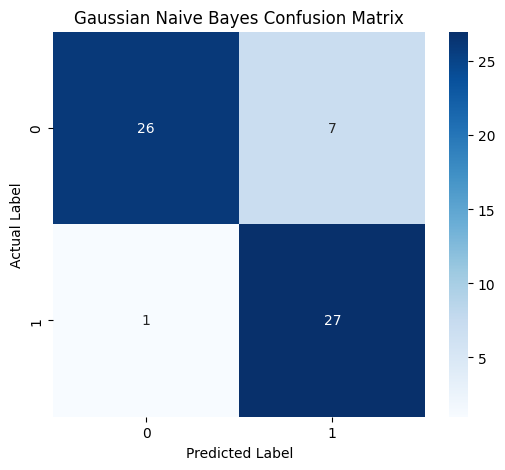

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

- Gaussian Naive Bayes was trained successfully on the Heart Disease dataset.
- The confusion matrix illustrates the model's prediction performance.
- The classification report provides precision, recall, F1-score, and overall accuracy, which will later be compared with other machine learning models.

# Model Performance Tracking

To compare multiple machine learning algorithms, the evaluation metrics of each model are stored in a results table.

This allows easy comparison of model performance at the end of the project.

In [34]:
# Store Gaussian Naive Bayes Results

results = []

results.append({
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_gnb),
    "Precision": precision_score(y_test, y_pred_gnb),
    "Recall": recall_score(y_test, y_pred_gnb),
    "F1 Score": f1_score(y_test, y_pred_gnb)
})

# Model 2: Logistic Regression

Logistic Regression is a widely used supervised machine learning algorithm for binary classification problems.

Since the algorithm is distance-based, feature scaling is applied before training.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_pred_lr = lr.predict(X_test_scaled)

In [38]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8689


In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



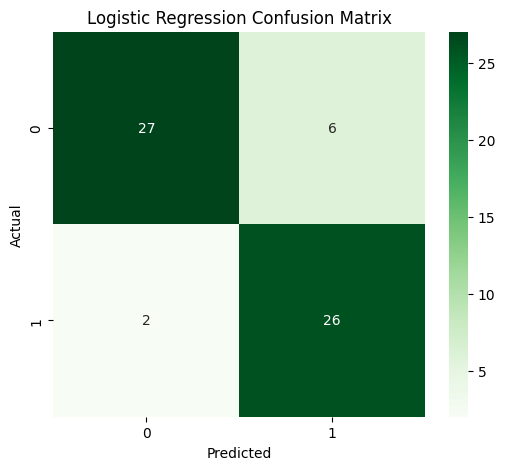

In [40]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
})

# Model 3: Decision Tree

Decision Trees classify data by learning a sequence of decision rules from the training data.

They are easy to interpret and can capture non-linear relationships between features.

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [43]:
y_pred_dt = dt.predict(X_test)

In [44]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7868852459016393


In [45]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



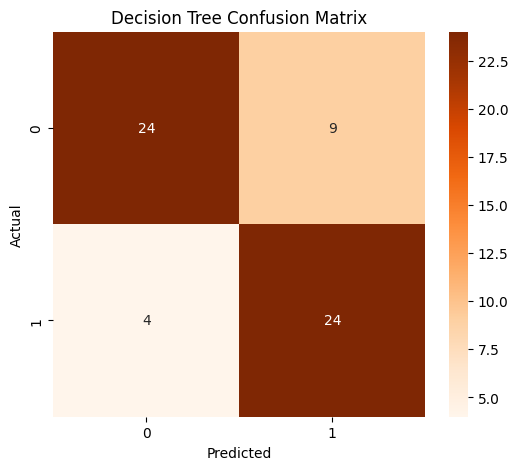

In [46]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy_score(y_test,y_pred_dt),
    "Precision":precision_score(y_test,y_pred_dt),
    "Recall":recall_score(y_test,y_pred_dt),
    "F1 Score":f1_score(y_test,y_pred_dt)
})

# Model 4: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is one of the most widely used algorithms for classification tasks.

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
y_pred_rf = rf.predict(X_test)

In [50]:
print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.8852459016393442


In [51]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



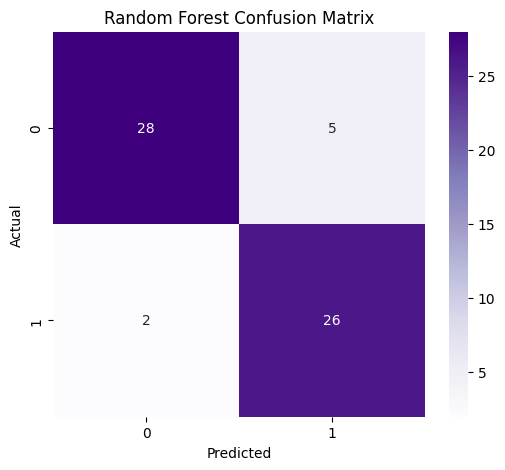

In [52]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy_score(y_test,y_pred_rf),
    "Precision":precision_score(y_test,y_pred_rf),
    "Recall":recall_score(y_test,y_pred_rf),
    "F1 Score":f1_score(y_test,y_pred_rf)
})

# Model Comparison

The performance of all trained machine learning models is compared using Accuracy, Precision, Recall, and F1-Score.

The best-performing model will be selected for the final prediction system.

In [54]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.885246,0.838710,0.928571,0.881356
0,Gaussian Naive Bayes,0.868852,0.794118,0.964286,0.870968
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667
2,Decision Tree,0.786885,0.727273,0.857143,0.786885


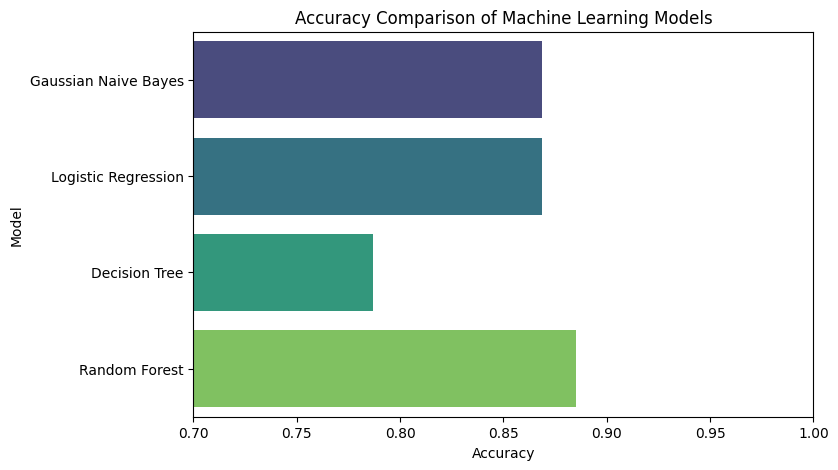

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlim(0.7,1.0)

plt.show()

### Observation

The comparison table shows the performance of all machine learning models.

The model with the highest accuracy and balanced evaluation metrics will be selected as the final prediction model.

# Saving the Best Model

Based on the performance comparison, the Random Forest classifier achieved the highest accuracy and was selected as the final model.

The trained model is saved using the `joblib` library for future predictions without retraining.

In [56]:
import joblib

joblib.dump(rf, "best_heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction.

Understanding feature importance helps identify the most influential clinical factors associated with heart disease.

In [57]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,thalach,0.135404
2,cp,0.127163
12,thal,0.122940
11,ca,0.100811
0,age,0.091327
9,oldpeak,0.089358
4,chol,0.088681
3,trestbps,0.080716
8,exang,0.050730
10,slope,0.046626


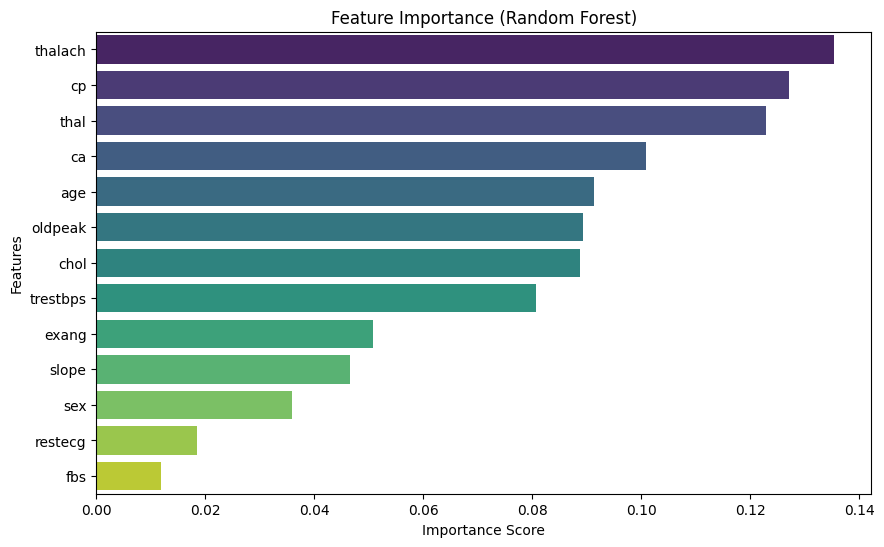

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

### Observation

- The Random Forest model assigns higher importance to features that contribute more to heart disease prediction.
- These features play a significant role in the model's decision-making process.
- Feature importance improves the interpretability of the machine learning model.

# Heart Disease Prediction Function

The following function accepts patient information and returns the predicted class using the trained Random Forest model.

In [59]:
def predict_heart_disease(patient_data):
    """
    Predict Heart Disease

    Parameters:
        patient_data (list): List containing 13 feature values

    Returns:
        Prediction
    """

    prediction = rf.predict([patient_data])[0]

    if prediction == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"

# Example Prediction

The following example demonstrates how the trained model can be used to predict heart disease for a new patient.

In [60]:
sample_patient = [
    63,     # age
    1,      # sex
    3,      # cp
    145,    # trestbps
    233,    # chol
    1,      # fbs
    0,      # restecg
    150,    # thalach
    0,      # exang
    2.3,    # oldpeak
    0,      # slope
    0,      # ca
    1       # thal
]

prediction = predict_heart_disease(sample_patient)

print(prediction)

No Heart Disease


# Conclusion

In this project, multiple supervised machine learning algorithms were implemented to predict the presence of heart disease using clinical patient data.

The project included:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Model comparison

Among the evaluated algorithms, the **Random Forest Classifier** achieved the highest prediction accuracy and was selected as the final model.

This project demonstrates how machine learning techniques can assist in the early detection of heart disease and support clinical decision-making.